# Scaling Optimal Transport with Hierarchical Refinement
---

**Ce notebook propose un tutorial implémentant la méthode de Hierarchical Refinement en utilsant la library ```OTT-JAX```**

### Rappel du problème :

> Optimal Transport (OT) est super utile en machine learning.

> Mais OT classique (Sinkhorn) explose en mémoire sur de gros jeux de données.

### Solution proposée :

Hierarchical Refinement (HiRef) résout ce problème en utilisant peu de mémoire, tout en fournissant une bijection.

### Plan du notebook :

1. Générer des données

2. Appliquer Low-rank OT

3. Appliquer Hierarchical Refinement

4. Visualiser et comparer

---

Notebook of work for implementing Hierarchical Refinement for OT

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.solvers.linear.sinkhorn import Sinkhorn
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn
from ott.tools.k_means import k_means
from ott.problems.linear import linear_problem
from ott.tools import plot


from typing import List, Tuple
import sys

In [3]:
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn

def partition_points(X: jnp.ndarray, k: int, rng: jax.random.PRNGKey) -> jnp.ndarray:
    """
    Partitionne un ensemble de points X en k groupes en utilisant
    Low-Rank Sinkhorn Optimal Transport (LRSinkhorn) comme décrit dans l'article
    Hierarchical Refinement.

    Paramètres :
    - X : jnp.ndarray, shape (N, d), nuage de points.
    - k : int, nombre de partitions (égal au rang du problème).
    - rng : jax.random.PRNGKey, clé aléatoire pour initialiser.

    Retour :
    - assignments : jnp.ndarray, shape (N,), étiquette de cluster pour chaque point.
    """

    # 1. Construire une géométrie sur (X, X)
    geom = pointcloud.PointCloud(X, X)

    # 2. Créer un problème de transport linéaire
    prob = linear_problem.LinearProblem(geom)

    # 3. Résoudre le problème Low-Rank Sinkhorn
    solver = LRSinkhorn(rank=k)
    out = solver(prob)

    # 4. Récupérer la matrice de transport
    transport_matrix = out.matrix  # shape (N, N)

    # 5. Calculer les assignations en regroupant les lignes de la matrice
    #    et en appliquant k-means ou une autre méthode de clustering si nécessaire.
    #    Ici, on utilise argmax pour une assignation simple.
    assignments = jnp.argmax(transport_matrix, axis=1)

    return assignments

In [4]:
def hierarchical_refinement_OLD2(
    X: jnp.ndarray,
    Y: jnp.ndarray,
    rank_schedule: List[int],
    rng: jax.random.PRNGKey = jax.random.key(0)
) -> List[Tuple[jnp.ndarray, jnp.ndarray]]:
    """
    Algorithme Hierarchical Refinement fidèle à l'article.
    """
    n = X.shape[0]
    t = 0
    blocks = [(X, Y)]
    base_rank = 1

    while any(min(X_block.shape[0], Y_block.shape[0]) > base_rank for (X_block, Y_block) in blocks):
        new_blocks = []
        rank = rank_schedule[t]
        rng, *subkeys = jax.random.split(rng, 2 * len(blocks) + 1)
        subkeys = iter(subkeys)

        for X_block, Y_block in blocks:
            n_pts = X_block.shape[0]

            if n_pts <= base_rank:
                new_blocks.append((X_block, Y_block))
                continue

            rng_X = next(subkeys)
            rng_Y = next(subkeys)

            assignment_X = partition_points(X_block, rank, rng_X)
            assignment_Y = partition_points(Y_block, rank, rng_Y)

            for z in range(rank):
                X_sub = X_block[assignment_X == z]
                Y_sub = Y_block[assignment_Y == z]

                # ✅ Ne conserver que les blocs non vides
                if X_sub.shape[0] > 0 and Y_sub.shape[0] > 0:
                    new_blocks.append((X_sub, Y_sub))

        blocks = new_blocks
        t += 1

    # ✅ Maintenant tous les blocs sont non vides et de taille (1, d)
    mapping = [(X_block.squeeze(0), Y_block.squeeze(0)) for (X_block, Y_block) in blocks]

    return mapping


In [5]:
def hierarchical_refinement_OLD1(X: jnp.ndarray, Y: jnp.ndarray, rank_schedule: list, rng: jax.random.PRNGKey = jax.random.key(0)) -> jnp.ndarray:
    """
    Applique l'algorithme de Hiérarchical Refinement pour approximer le transport optimal entre X et Y.

    Paramètres :
    - X : jnp.ndarray de forme (N, d), premier ensemble de points.
    - Y : jnp.ndarray de forme (N, d), second ensemble de points.
    - rank_schedule : liste d'entiers, nombre de clusters à chaque niveau de la hiérarchie.
    - rng : jax.random.PRNGKey, clé aléatoire pour l'initialisation.

    Retourne :
    - assignments : jnp.ndarray de forme (N,), indices des correspondances finales entre X et Y.
    """
    N = X.shape[0]
    assignments = jnp.arange(N)
    
    for i, rank in enumerate(rank_schedule):
        rng, rng_X, rng_Y = jax.random.split(rng, 3)
        # Partitionner X et Y en clusters
        assignment_X = partition_points(X, k=rank, rng = rng_X)
        assignment_Y = partition_points(Y, k=rank, rng = rng_Y)
        new_assignments = jnp.zeros_like(assignments)
        for cluster_id in range(rank):
            idx_X = jnp.where(assignment_X == cluster_id)[0]
            idx_Y = jnp.where(assignment_Y == cluster_id)[0]
            if idx_X.size == 0 or idx_Y.size == 0:
                continue
            X_sub = X[idx_X]
            Y_sub = Y[idx_Y]
            # On assigne à tous les points le poids
            a = jnp.ones((X_sub.shape[0],)) / X_sub.shape[0]
            b = jnp.ones((Y_sub.shape[0],)) / Y_sub.shape[0]
            geom = pointcloud.PointCloud(X_sub, Y_sub)
            ot_prob = linear_problem.LinearProblem(geom, a, b)
            solver = LRSinkhorn(rank=rank)
            out = solver(ot_prob)
            transport_matrix = out.matrix

            # Trouver les correspondances maximales
            sub_assignments = jnp.argmax(transport_matrix, axis=1)
            # Mettre à jour les correspondances globales
            new_assignments = new_assignments.at[idx_X].set(idx_Y[sub_assignments])

        
        # Mettre à jour X et Y pour le niveau suivant
        X = X[new_assignments]
        Y = Y[new_assignments]
        assignments = new_assignments
    return assignments


In [6]:
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn

def hierarchical_refinement(X: jnp.ndarray, Y: jnp.ndarray, rank_schedule: list, rng: jax.random.PRNGKey = jax.random.PRNGKey(0)) -> jnp.ndarray:
    """
    Applique l'algorithme de Hiérarchical Refinement pour approximer le transport optimal entre X et Y.

    Paramètres :
    - X : jnp.ndarray de forme (N, d), premier ensemble de points.
    - Y : jnp.ndarray de forme (N, d), second ensemble de points.
    - rank_schedule : liste d'entiers, nombre de clusters à chaque niveau de la hiérarchie.
    - rng : jax.random.PRNGKey, clé aléatoire pour l'initialisation.

    Retourne :
    - assignments : jnp.ndarray de forme (N,), indices des correspondances finales entre X et Y.
    """
    N = X.shape[0]
    assignments = jnp.arange(N)

    for i, rank in enumerate(rank_schedule):
        rng, rng_X, rng_Y = jax.random.split(rng, 3)
        # Partitionner X et Y en clusters
        assignment_X = partition_points(X, rank, rng_X)
        assignment_Y = partition_points(Y, rank, rng_Y)
        new_assignments = jnp.zeros_like(assignments)
        for cluster_id in range(rank):
            idx_X = jnp.where(assignment_X == cluster_id)[0]
            idx_Y = jnp.where(assignment_Y == cluster_id)[0]
            if idx_X.size == 0 or idx_Y.size == 0:
                continue
            X_sub = X[idx_X]
            Y_sub = Y[idx_Y]
            # On assigne à tous les points le poids
            a = jnp.ones((X_sub.shape[0],)) / X_sub.shape[0]
            b = jnp.ones((Y_sub.shape[0],)) / Y_sub.shape[0]
            geom = pointcloud.PointCloud(X_sub, Y_sub)
            ot_prob = linear_problem.LinearProblem(geom, a, b)
            #solver = LRSinkhorn(rank=rank)
            solver = sinkhorn.Sinkhorn()
            out = solver(ot_prob)
            transport_matrix = out.matrix

            # Trouver les correspondances maximales
            sub_assignments = jnp.argmax(transport_matrix, axis=1)
            # Mettre à jour les correspondances globales
            new_assignments = new_assignments.at[idx_X].set(idx_Y[sub_assignments])

        # Mettre à jour X et Y pour le niveau suivant
        X = X[new_assignments]
        Y = Y[new_assignments]
        assignments = new_assignments
    return assignments


In [7]:
sys.path.insert(0, '../nbk_HiRef/')

## Autre fonction fournit pas Chat GPT 4.5

In [8]:
import jax
import jax.numpy as jnp
from jax import vmap
from functools import partial


def low_rank_ot(X, Y, rank, rng):
    # Méthode simplifiée : k-means pour partitionner
    def kmeans_step(points, centroids):
        dists = jnp.linalg.norm(points[:, None, :] - centroids[None, :, :], axis=2)
        labels = jnp.argmin(dists, axis=1)
        new_centroids = vmap(lambda c: points[labels == c].mean(axis=0))(jnp.arange(rank))
        return new_centroids

    centroids_X = jax.random.choice(rng, X, shape=(rank,), replace=False)
    centroids_Y = jax.random.choice(rng, Y, shape=(rank,), replace=False)

    for _ in range(10):
        centroids_X = kmeans_step(X, centroids_X)
        centroids_Y = kmeans_step(Y, centroids_Y)

    labels_X = jnp.argmin(jnp.linalg.norm(X[:, None, :] - centroids_X[None, :, :], axis=2), axis=1)
    labels_Y = jnp.argmin(jnp.linalg.norm(Y[:, None, :] - centroids_Y[None, :, :], axis=2), axis=1)

    return labels_X, labels_Y


def hierarchical_refinement(X: jnp.ndarray, Y: jnp.ndarray, rank_schedule: list, rng: jax.random.PRNGKey = jax.random.PRNGKey(0)) -> jnp.ndarray:
    N = X.shape[0]
    assignments = jnp.arange(N)

    def refine(X_indices, Y_indices, level, rng):
        if level == len(rank_schedule):
            return [(X_indices, Y_indices)]

        rank = rank_schedule[level]
        X_subset, Y_subset = X[X_indices], Y[Y_indices]
        labels_X, labels_Y = low_rank_ot(X_subset, Y_subset, rank, rng) ## Ne fonctionne pas

        clusters = []
        for r in range(rank):
            X_r = X_indices[labels_X == r]
            Y_r = Y_indices[labels_Y == r]

            if X_r.size > 0 and Y_r.size > 0:
                rng, subrng = jax.random.split(rng)
                clusters.extend(refine(X_r, Y_r, level + 1, subrng))

        return clusters

    clusters = refine(jnp.arange(N), jnp.arange(N), 0, rng)

    final_assignment = jnp.zeros(N, dtype=int)
    for X_idx, Y_idx in clusters:
        final_assignment = final_assignment.at[X_idx].set(Y_idx)

    assignments_matrix = jnp.zeros((N, N))
    assignments_matrix = assignments_matrix.at[jnp.arange(N), final_assignment].set(1)

    return assignments_matrix

## Génération de données

In [9]:
nombre_points = 128

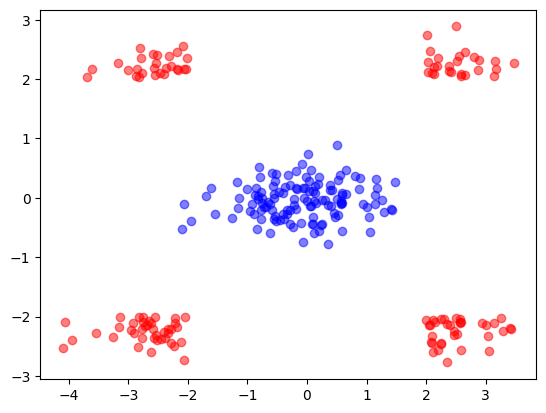

In [10]:
import toy_example

X1, X2 = toy_example.generate_sample_data(N = nombre_points)

# On transforme les vecteurs X1 et X2 au format jnp
X1 = jnp.array(X1)
X2 = jnp.array(X2)

In [11]:
X1.shape

(128, 2)

In [12]:
# plt.scatter(X1[:, 0], X1[:, 1], label="Source", alpha=0.6)
# plt.scatter(X2[:, 0], X2[:, 1], label="Target", alpha=0.6)
# plt.legend()
# plt.title("Source and Target point clouds")
# plt.show()

## Low-Rank OT brut
A partir de ce tuto [OTT-JAX Low-Rank Sinkhorn](https://ott-jax.readthedocs.io/en/stable/tutorials/linear/300_LRSinkhorn.html)

---

Les algorithmes de transport optimal, tels que Sinkhorn ou LRSinkhorn dans la bibliothèque OTT-JAX, 
nécessitent des distributions de probabilité en entrée. 

Cela signifie que les poids a et b doivent être des vecteurs de probabilités, 
c'est-à-dire des vecteurs non négatifs dont la somme est égale à 1.

---


In [13]:
# On transforme les vecteurs numpy X1 et X2 en vecteur JNP
X1 = jnp.array(X1)
X2 = jnp.array(X2)

# On assigne à tous les points le poids
a = jnp.ones((X1.shape[0],)) / X1.shape[0]
b = jnp.ones((X2.shape[0],)) / X2.shape[0]


### Classic Sinkhorn

In [14]:
geom = pointcloud.PointCloud(X1, X2, epsilon=0.1)
ot_prob = linear_problem.LinearProblem(geom, a, b)

solver = Sinkhorn()
ot_sink = solver(ot_prob)

In [15]:
if nombre_points <= 64:
    solver = Sinkhorn()
    ot_sink = solver(ot_prob)

    plt.imshow(ot_sink.matrix, cmap="Purples")
    plt.title(f"Sinkhorn cost: {ot_sink.primal_cost:.4f}")
    plt.colorbar()
    plt.show()
    plott = plot.Plot()
    _ = plott(ot_sink)
    
else :
    pass

### Low-rank Sinkhorn

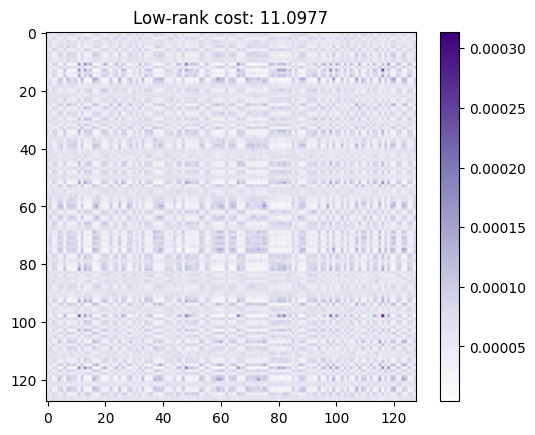

In [16]:
n = X1.shape[0]

solver = LRSinkhorn(rank=int(n / 2)) # Possibility to increase to rank to improve precision and reduce Transport cost
ot_lr = solver(ot_prob)

plt.imshow(ot_lr.matrix, cmap="Purples")
plt.colorbar()
plt.title(f"Low-rank cost: {ot_lr.primal_cost:.4f}")
plt.show()

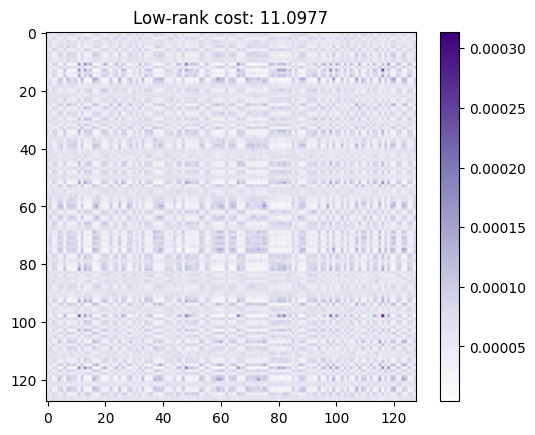

In [17]:
plt.imshow(ot_lr.matrix, cmap="Purples")
plt.colorbar()
plt.title(f"Low-rank cost: {ot_lr.primal_cost:.4f}")
plt.show()

In [18]:
if nombre_points <= 64:
    plott = plot.Plot()
    _ = plott(ot_lr)
else:
    pass

In [19]:
type(ot_lr.matrix)

jaxlib.xla_extension.ArrayImpl

## Hierarchical Refinement

In [20]:
from src import rank_annealing

rank_schedule = rank_annealing.optimal_rank_schedule(nombre_points , hierarchy_depth = 16, max_Q = 4, max_rank = 4)
rank_schedule

/home/onyxia/work/ENSAE-OT_Projet/nbk/../nbk_HiRef/src/rank_annealing.py:11: SyntaxWarning: invalid escape sequence '\l'
  """
/home/onyxia/work/ENSAE-OT_Projet/nbk/../nbk_HiRef/src/rank_annealing.py:60: SyntaxWarning: invalid escape sequence '\l'
  """
/home/onyxia/work/ENSAE-OT_Projet/nbk/../nbk_HiRef/src/rank_annealing.py:11: SyntaxWarning: invalid escape sequence '\l'
  """
/home/onyxia/work/ENSAE-OT_Projet/nbk/../nbk_HiRef/src/rank_annealing.py:60: SyntaxWarning: invalid escape sequence '\l'
  """


ModuleNotFoundError: No module named 'torch'

In [ ]:
mapping = hierarchical_refinement(
    X1, X2,
    rank_schedule=rank_schedule,  # Exemple de découpe hiérarchique --> la somme de nombre de la liste doit être égal au nombre de point à transporter --> e.g. pour 16 point prendre [2, 2, 4] car 2 * 2 * 4 = 16
)

NonConcreteBooleanIndexError: Array boolean indices must be concrete; got ShapedArray(bool[128])

See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.NonConcreteBooleanIndexError

> 1024 points réalisé en 1min23.8 secondes en utilisant un solveur ```sinkhorn classique```
avec le Optimized rank-annealing schedule: [2, 4, 4, 4, 4, 2]

> 1024 points réalisé en 56.3 secondes en utilisant un solveur ```sinkhorn LR```
avec le Optimized rank-annealing schedule: [2, 4, 4, 4, 4, 2] --> Mais problème, solution absolument pas bijective...


In [ ]:
mapping

Array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [ ]:
values, counts = jnp.unique(mapping, return_counts=True)
counts
values

Array([0], dtype=int32)

## Visualisation des correspondances

## Comparaison des Coûts

# Conclusion

Résumé :

- HiRef permet d’obtenir un transport optimal bijectif.
- Il économise beaucoup de mémoire. (stockage linéaire VS n^2)
- Il est compétitif en coût avec Sinkhorn mais scalable à des millions de points.

Liens :
- Lien vers le papier original 📄.
- Lien vers le code HiRef sur GitHub 🔗.